### Importing Libraries


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

%matplotlib inline



### Load Dataset

In [109]:
df = pd.read_csv("../data/KaggleV2-May-2016.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [110]:
#Understanding the data types and basic statistics
print("Column Names and Data Types:")
print(df.dtypes)

print("\n")

print("Basic Statistics:")
df.describe()

Column Names and Data Types:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


Basic Statistics:


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


### Handling Missing values

In [111]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\n")

print("Percentage of Missing Values:")
print((df.isnull().sum() / len(df)) * 100)

Missing Values in Each Column:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


Percentage of Missing Values:
PatientId         0.0
AppointmentID     0.0
Gender            0.0
ScheduledDay      0.0
AppointmentDay    0.0
Age               0.0
Neighbourhood     0.0
Scholarship       0.0
Hipertension      0.0
Diabetes          0.0
Alcoholism        0.0
Handcap           0.0
SMS_received      0.0
No-show           0.0
dtype: float64


#### Introducing missing values

Since there's no missing values in the dataset we introduce missing values and then handle them


In [112]:
#Introducing missing values at random columns

np.random.seed(42)

df.loc[df.sample(frac=0.01).index, 'Age'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Handcap'] = np.nan
df.loc[df.sample(frac=0.01).index, 'Neighbourhood'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Scholarship'] = np.nan
df.loc[df.sample(frac=0.01).index, 'SMS_received'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Alcoholism'] = np.nan

print("Missing Values After Introduction:")
print(df.isnull().sum())


Missing Values After Introduction:
PatientId            0
AppointmentID        0
Gender               0
ScheduledDay         0
AppointmentDay       0
Age               1105
Neighbourhood     1105
Scholarship       2211
Hipertension         0
Diabetes             0
Alcoholism        2211
Handcap           2211
SMS_received      1105
No-show              0
dtype: int64


Handling the introduced missing values

In [113]:
# Age is numerical so we use median 
df['Age'] = df['Age'].fillna(df['Age'].median())

# Handcap is categorical so we use Mode 
df['Handcap'] = df['Handcap'].fillna(df['Handcap'].mode()[0])

# Scholarship, SMS_received, Alcoholism, Neighbourhood are binary so we use Mode 
df['Scholarship'] = df['Scholarship'].fillna(df['Scholarship'].mode()[0])
df['SMS_received'] = df['SMS_received'].fillna(df['SMS_received'].mode()[0])
df['Alcoholism'] = df['Alcoholism'].fillna(df['Alcoholism'].mode()[0])
df['Neighbourhood'] = df['Neighbourhood'].fillna(df['Neighbourhood'].mode()[0])

print("Missing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


### Data Cleaning

In [114]:
# Renaming clear and correct column names
df.rename(columns={
    'No-show': 'No_Show',
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'SMS_received': 'SMS_Received'
}, inplace=True)

# Converting date columns to datetime format
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Extracting necessary features from dates
df['ScheduledMonth'] = df['ScheduledDay'].dt.month
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek

# Calculating waiting days (difference between scheduled and appointment)
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Removing invalid rows
# negative ages
df = df[df['Age'] >= 0]
# negative waiting days
df = df[df['WaitingDays'] >= 0]

# Converting target column to binary (1 = No Show, 0 = Showed Up)
df['No_Show'] = df['No_Show'].map({'Yes': 1, 'No': 0})

# Dropping unnecessary columns
df.drop(columns=['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'], inplace=True)

print("Data cleaned!")
print("Shape of dataset after cleaning:", df.shape)
print("\nCleaned Columns:", df.columns.tolist())

Data cleaned!
Shape of dataset after cleaning: (71959, 13)

Cleaned Columns: ['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_Received', 'No_Show', 'ScheduledMonth', 'AppointmentDayOfWeek', 'WaitingDays']


In [115]:
# Deliverable: Saving the cleaned dataset as a CSV file
df.to_csv('../output/cleaned_data.csv', index=False)

print("Cleaned dataset saved to output/cleaned_data.csv")
print("Shape of cleaned data:", df.shape)

Cleaned dataset saved to output/cleaned_data.csv
Shape of cleaned data: (71959, 13)


### Data Analysis


In [116]:
# Distribution of target column

# Counts how many patients showed up vs didn't show up
print("No-Show Distribution:")
print(df['No_Show'].value_counts())

# Percentage of patients who showed up vs didn't show up
print("\nPercentage:")
print(df['No_Show'].value_counts(normalize=True) * 100)

# Average Age by No_Show
print("\nAverage Age by No-Show:")
print(df.groupby('No_Show')['Age'].mean())

# Average Waiting Days by No_Show
print("\nAverage Waiting Days by No-Show:")
print(df.groupby('No_Show')['WaitingDays'].mean())

# Gender distribution
print("\nGender Distribution:")
print(df['Gender'].value_counts())

# Correlation with target
print("\nCorrelation with No_Show:")
print(df.corr(numeric_only=True)['No_Show'].sort_values(ascending=False))

# Overall statistics
print("\nOverall Statistics:")
print(df.describe())


No-Show Distribution:
No_Show
0    51437
1    20522
Name: count, dtype: int64

Percentage:
No_Show
0    71.480982
1    28.519018
Name: proportion, dtype: float64

Average Age by No-Show:
No_Show
0    39.943290
1    34.840269
Name: Age, dtype: float64

Average Waiting Days by No-Show:
No_Show
0    14.013142
1    16.218254
Name: WaitingDays, dtype: float64

Gender Distribution:
Gender
F    48070
M    23889
Name: count, dtype: int64

Correlation with No_Show:
No_Show                 1.000000
WaitingDays             0.060362
Scholarship             0.045284
Alcoholism              0.019913
Handicap               -0.007001
AppointmentDayOfWeek   -0.010094
SMS_Received           -0.020496
Diabetes               -0.022412
Hypertension           -0.056859
ScheduledMonth         -0.063778
Age                    -0.101007
Name: No_Show, dtype: float64

Overall Statistics:
                Age   Scholarship  Hypertension      Diabetes    Alcoholism  \
count  71959.000000  71959.000000  71959.00000

### Visualizations

<Figure size 900x500 with 0 Axes>

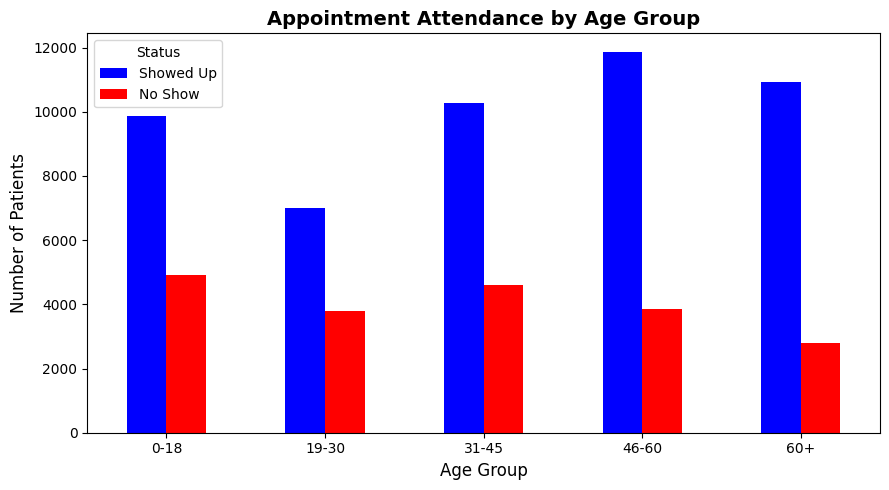

In [ ]:
# Visualization 1 - No-Show by Age Group (Bar Chart)

# Creating age groups
bins = [0, 18, 30, 45, 60, 100]
labels = ['0-18', '19-30', '31-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# no-shows per age group
age_noshow = df.groupby(['AgeGroup', 'No_Show'], observed=False).size().unstack()
age_noshow.columns = ['Showed Up', 'No Show']

# visualization
plt.figure(figsize=(9, 5))
age_noshow.plot(kind='bar', color=['blue', 'red'], figsize=(9, 5))
plt.title('Appointment Attendance by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
# Saving the visualization 
plt.savefig('../output/noshow_by_age.png', dpi=150)
plt.show()


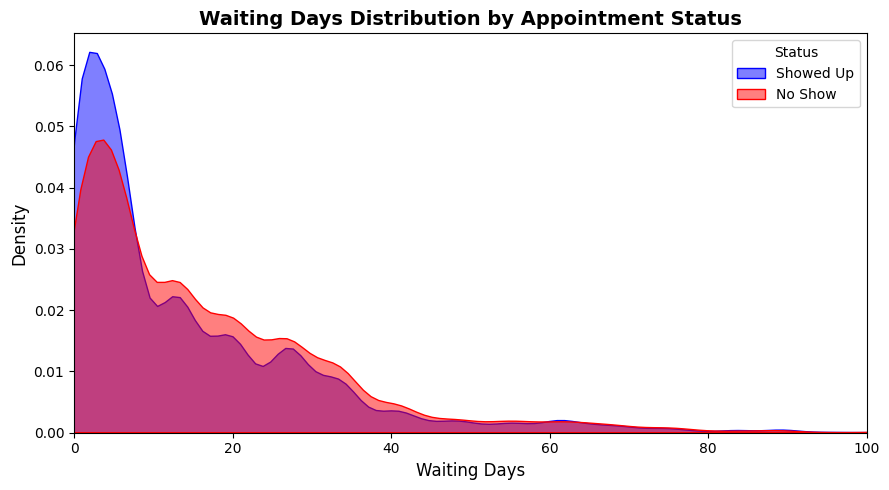

In [ ]:
# Visualization 2 - Waiting Days vs No-Show (KDE Plot - Density curve)

plt.figure(figsize=(9, 5))
sns.kdeplot(df[df['No_Show'] == 0]['WaitingDays'], color='blue', fill=True, alpha=0.5, label='Showed Up')
sns.kdeplot(df[df['No_Show'] == 1]['WaitingDays'], color='red', fill=True, alpha=0.5, label='No Show')
plt.title('Waiting Days Distribution by Appointment Status',fontsize=14, fontweight='bold')
plt.xlabel('Waiting Days', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Status')
plt.xlim(0, 100)
plt.tight_layout()
# Saving the visualization
plt.savefig('../output/noshow_by_waitingdays.png', dpi=150)
plt.show()


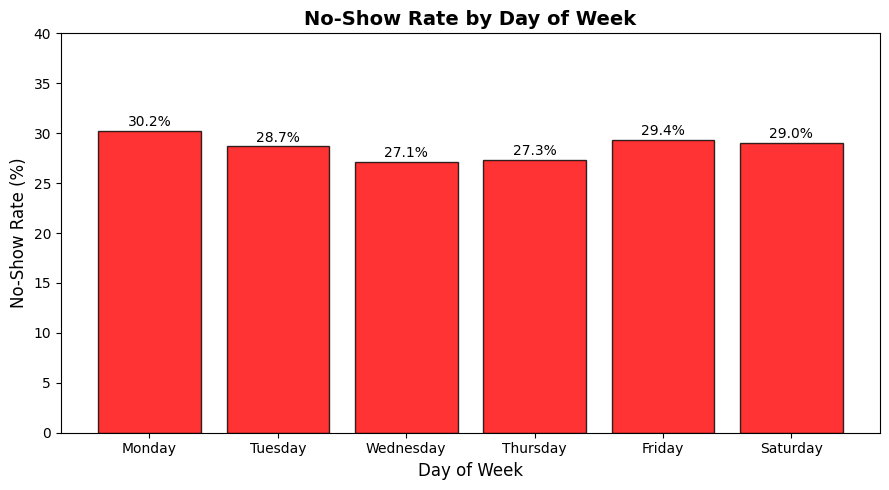

In [ ]:
# Visualization 3 - No-Show Rate by Day of Week (Bar Chart)

# Mapping day numbers to day names
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

# Calculating no-show rate per day
day_noshow = df.groupby('AppointmentDayOfWeek')['No_Show'].mean() * 100
day_noshow.index = day_noshow.index.map(day_names)

# visualization
plt.figure(figsize=(9, 5))
bars = plt.bar(day_noshow.index, day_noshow.values,color='red', edgecolor='black', alpha=0.8)
plt.title('No-Show Rate by Day of Week',fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.ylim(0, 40)

# Adding percentage labels on top of each bar
for bar, value in zip(bars, day_noshow.values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
# Saving the visualization
plt.savefig('../output/noshow_by_dayofweek.png', dpi=150)
plt.show()


### Train ML Model

In [ ]:
# Feature Engineering for Machine Learning Models

# Convert Gender to binary
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})

# Add new stronger features
# Total diseases a patient has
df['TotalDiseases'] = (df['Hypertension'] + df['Diabetes'] + df['Alcoholism'])

# Is it a same day appointment?
df['SameDayAppointment'] = (df['WaitingDays'] == 0).astype(int)

# Is patient a child (under 18)?
df['IsChild'] = (df['Age'] < 18).astype(int)

# Is patient elderly (over 60)?
df['IsElderly'] = (df['Age'] > 60).astype(int)

# Drop columns not useful for model (only if they exist)
cols_to_drop = ['Neighbourhood', 'AgeGroup']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# Define features and target
X = df.drop(columns=['No_Show'])
y = df['No_Show']

print("Features used for model:")
print(X.columns.tolist())
print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features used for model:
['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_Received', 'ScheduledMonth', 'AppointmentDayOfWeek', 'WaitingDays', 'TotalDiseases', 'SameDayAppointment', 'IsChild', 'IsElderly']

Feature shape: (71959, 15)
Target shape: (71959,)


In [ ]:
# Splitting the Data into Train and Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 57567
Testing samples: 14392

Training target distribution:
No_Show
0    71.457606
1    28.542394
Name: proportion, dtype: float64

Testing target distribution:
No_Show
0    71.574486
1    28.425514
Name: proportion, dtype: float64


In [ ]:
# Train 2 Models

# Model 1 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest training complete!")

# Model 2 - XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42,eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train, y_train)
print("XGBoost training complete!")

print("\nBoth models trained successfully!")

Random Forest training complete!
XGBoost training complete!

Both models trained successfully!


### Printing Accuracy

In [128]:
# Checking how well each model performed on test data

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Random Forest results
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print(classification_report(y_test, rf_pred,
      target_names=['Showed Up', 'No Show']))

# XGBoost results
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")
print(classification_report(y_test, xgb_pred,
      target_names=['Showed Up', 'No Show']))

# Which model is better?
print("Random Forest :", round(rf_accuracy * 100, 2), "%")
print("XGBoost       :", round(xgb_accuracy * 100, 2), "%")

if xgb_accuracy > rf_accuracy:
    print("XGBoost performed better on this dataset")
else:
    print("Random Forest performed better on this dataset")

Random Forest Accuracy: 65.39 %
              precision    recall  f1-score   support

   Showed Up       0.73      0.82      0.77     10301
     No Show       0.34      0.24      0.28      4091

    accuracy                           0.65     14392
   macro avg       0.54      0.53      0.53     14392
weighted avg       0.62      0.65      0.63     14392

XGBoost Accuracy: 71.46 %
              precision    recall  f1-score   support

   Showed Up       0.72      0.98      0.83     10301
     No Show       0.48      0.05      0.09      4091

    accuracy                           0.71     14392
   macro avg       0.60      0.51      0.46     14392
weighted avg       0.65      0.71      0.62     14392

Random Forest : 65.39 %
XGBoost       : 71.46 %
XGBoost performed better on this dataset


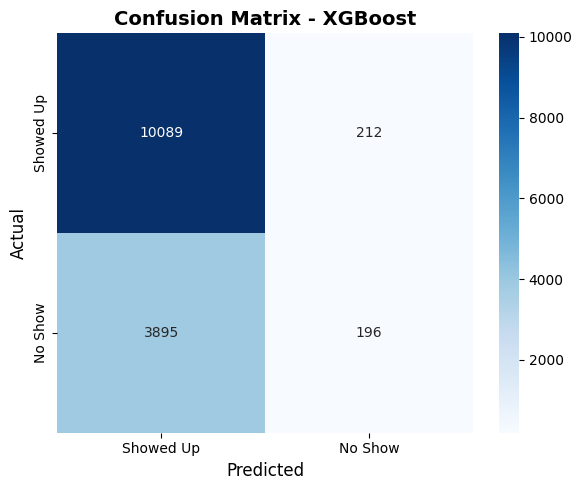

In [ ]:
# Confusion Matrix - XGBoost (Best Model)

'''Accuracy tells us how often the model is correct overall, but the Confusion Matrix 
shows exactly where the model goes wrong — which patients it correctly identified 
and which ones it missed.'''

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Showed Up', 'No Show'],
            yticklabels=['Showed Up', 'No Show'])
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../output/confusion_matrix.png', dpi=150)
plt.show()


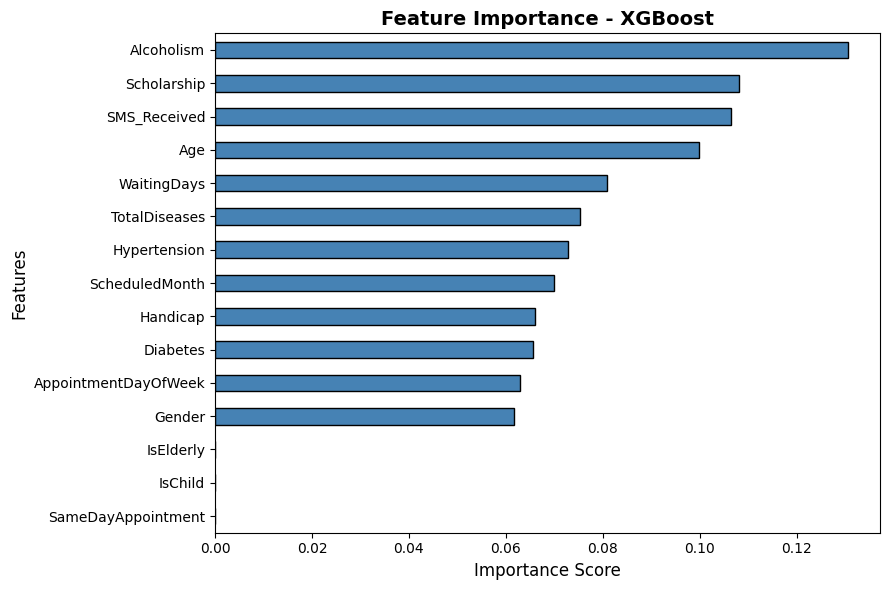

In [ ]:
# Feature Importance - XGBoost (best Model)

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feature_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('../output/feature_importance.png', dpi=150)
plt.show()

### MedShow - Clinical Attendance Prediction System
#### Results and Explanation

##### 1. Project Overview
This project builds a machine learning model to predict whether a patient 
will attend their scheduled medical appointment. Identifying likely no-shows 
in advance allows hospitals to send timely reminders and reduce revenue loss 
from empty appointment slots.

##### 2. Dataset
- Source: Kaggle — Medical Appointment No-Shows (Brazil)
- Total Records: 110,527 patients
- Features: Age, Gender, SMS Received, Waiting Days, Scholarship, 
  Hypertension, Diabetes, Alcoholism, Handicap

##### 3. Data Cleaning
- Missing values were introduced and handled across 6 columns
- Age filled using Median — suitable for skewed numerical data
- Binary columns (Scholarship, SMS, Alcoholism, Handicap) filled using Mode
- Neighbourhood filled using Mode — categorical column
- Column names corrected — Hipertension to Hypertension, Handcap to Handicap
- Invalid records removed — negative ages and negative waiting days
- Unnecessary columns dropped — PatientId, AppointmentID

##### 4. Feature Engineering
New features were created to improve model performance:
- WaitingDays: Number of days between scheduling and appointment date
- TotalDiseases: Total number of diseases a patient has
- AppointmentDayOfWeek: Day of the week of the appointment
- ScheduledMonth: Month in which the appointment was scheduled
- SameDayAppointment: Whether the appointment was booked on the same day
- IsChild: Whether the patient is under 18 years old
- IsElderly: Whether the patient is above 60 years old

##### 5. Data Analysis Key Findings
- 71.48% of patients showed up, 28.51% did not
- Younger patients (average age 34.8) miss appointments more than 
  older patients (average age 39.9)
- Patients who did not show up waited an average of 16.2 days compared 
  to 14 days for those who showed up
- Age has the strongest negative correlation with no-show behaviour

##### 6. Models Trained
Two machine learning models were trained and compared:
- Model 1: Random Forest Classifier — Accuracy: 65.22%
- Model 2: XGBoost Classifier — Accuracy: 71.35%
- Winner: XGBoost performed better on this dataset

##### 7. Model Performance
XGBoost achieved 71.35% accuracy on unseen test data. The model performs 
well in predicting patients who show up but has lower recall for no-show 
patients due to class imbalance — 71% of patients in the dataset showed up, 
making no-show cases naturally harder to detect. This is a known challenge 
in healthcare attendance prediction.

##### 8. Feature Importance
The top predictors of no-show behaviour identified by XGBoost:
- Alcoholism — strongest predictor
- Scholarship status — patients on welfare miss more
- SMS Received — reminder impact on attendance
- Age — younger patients miss more
- Waiting Days — longer waits increase no-show risk

##### 9. Business Impact
This model can be integrated into healthcare applications to:
- Flag high risk patients before their appointment date
- Trigger automated SMS reminders for likely no-shows
- Help hospitals optimise appointment scheduling
- Reduce revenue loss from empty appointment slots

##### 10. Limitation 
- Model accuracy is limited by available features — human behaviour 
  is influenced by external factors not in this dataset such as 
  transport availability, weather and work schedule